In [1]:
print("Comparing Original and Improved Models regarding Jigsaw Events VOL001 data using R Squared and RMSE metrics:")

Comparing Original and Improved Models regarding Jigsaw Events VOL001 data using R Squared and RMSE metrics:


In [13]:
import pandas as pd
df = pd.read_csv("../data/JE001_real_improved.csv")
df.head(10)

,date,tickets_sold,instagram_followers,reel_views,days_advertised,day_of_week,month,student_term_time,weather,rainfall,...,campaign_progress,is_weekend,is_student_holiday,temperature_celsius,rainfall_mm,has_rain,rain_severity,temperature_severity,weather_severity,overall_severity
0,2026-07-19,9,49,674,14,Sunday,July,Summer Break,Sunny,0mm,...,0.297872,1,1,24.0,0.0,0,0,0,0,0
1,2026-07-23,11,57,898,18,Thursday,July,Summer Break,Cloudy,0mm,...,0.382979,0,1,19.0,0.0,0,0,0,1,1
2,2026-07-28,18,73,1535,23,Tuesday,July,Summer Break,Sunny,0mm,...,0.489362,0,1,25.0,0.0,0,0,1,0,1
3,2026-07-31,19,74,1569,26,Friday,July,Summer Break,Sunny,0mm,...,0.553191,0,1,20.0,0.0,0,0,0,0,0
4,2026-08-06,25,76,1593,32,Thursday,August,Summer Break,Cloudy,1mm,...,0.680851,0,1,15.0,1.0,1,1,0,1,2
5,2026-08-08,32,77,1603,34,Saturday,August,Summer Break,Sunny,0mm,...,0.723404,1,1,20.0,0.0,0,0,0,0,0
6,2026-08-12,41,78,1642,38,Wednesday,August,Summer Break,Sunny,0mm,...,0.808511,0,1,26.0,0.0,0,0,1,0,1
7,2026-08-17,53,81,1687,43,Monday,August,Summer Break,Cloudy,1mm,...,0.914894,0,1,20.0,1.0,1,1,0,1,2
8,2026-08-21,98,91,1852,48,Friday,August,Summer Break,Sunny,0mm,...,1.000000,0,1,21.0,0.0,0,0,0,0,0


In [14]:
improved_features = ["instagram_followers","reel_views","days_advertised","rainfall_mm","temperature_celsius","reel_views_per_follower","campaign_progress", "overall_severity","is_student_holiday"]

In [15]:
X_improved = df[improved_features]
y_improved = df["tickets_sold"]

In [16]:
from sklearn.model_selection import train_test_split

X_improved_train, X_improved_test, y_improved_train, y_improved_test = train_test_split (X_improved, y_improved, test_size=0.2, random_state=42)

In [17]:
from sklearn.ensemble import RandomForestRegressor

improved_model = RandomForestRegressor(n_estimators=100,random_state=42)

improved_model.fit(X_improved_train, y_improved_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [18]:
_improved_predictions = improved_model.predict(X_improved_test)

In [19]:
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42)
train = df.loc[train_idx]
test = df.loc[test_idx]

In [20]:
improved_predictions = improved_model.predict(X_improved_test)

print(improved_predictions[:10])

[43.4  17.45]


In [22]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

improved_r2 = r2_score( y_improved_test,improved_predictions)

improved_rmse = np.sqrt(mean_squared_error(y_improved_test,improved_predictions))

print(f"Improved R²: {improved_r2:.3f}")
print(f"Improved RMSE: {improved_rmse:.2f}")

Improved R²: 0.848
Improved RMSE: 8.18


In [23]:
original_features = ["instagram_followers","reel_views","days_advertised"]

X_original = df[original_features]
y_original = df["tickets_sold"]

X_original_train, X_original_test, y_original_train, y_original_test = train_test_split(X_original,y_original,test_size=0.2,random_state=42)

In [24]:
original_model = RandomForestRegressor(n_estimators=100,random_state=42)

original_model.fit(X_original_train,y_original_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [25]:
original_predictions = original_model.predict(X_original_test)

print(original_predictions)

[41.78 12.17]


In [26]:
original_r2 = r2_score(y_original_test,original_predictions)

original_rmse = np.sqrt(mean_squared_error(y_original_test,original_predictions))

print(f"Original R²: {original_r2:.3f}")
print(f"Original RMSE: {original_rmse:.2f}")

Original R²: 0.856
Original RMSE: 7.98


In [27]:
comparison = pd.DataFrame({"Model": ["Original","Improved"],"R2": [original_r2,improved_r2],"RMSE": [original_rmse,improved_rmse]})
comparison

,Model,R2,RMSE
0,Original,0.855717,7.976757
1,Improved,0.848342,8.178096


In [28]:
r2_change = improved_r2 - original_r2
rmse_change = improved_rmse - original_rmse

print(f"R² change: {r2_change:+.3f}")
print(f"RMSE change: {rmse_change:+.2f}")

R² change: -0.007
RMSE change: +0.20


In [2]:
print("Model importance and final evaluation of the models:")

Model importance and final evaluation of the models:


In [30]:
improved_model.feature_importances_

array([0.23706402, 0.29985017, 0.25821441, 0.00306036, 0.01587157,
       0.06338713, 0.108366  , 0.01418634, 0.        ])

In [ ]:
feature_importance = pd.DataFrame({"feature": improved_features, "importance": improved_model.feature_importances_})

In [32]:
feature_importance = feature_importance.sort_values(by="importance", ascending=False)

In [34]:
df = feature_importance

In [35]:
df.head(10)

,feature,importance
1,reel_views,0.299850
2,days_advertised,0.258214
0,instagram_followers,0.237064
6,campaign_progress,0.108366
5,reel_views_per_follower,0.063387
4,temperature_celsius,0.015872
7,overall_severity,0.014186
3,rainfall_mm,0.003060
8,is_student_holiday,0.000000


In [36]:
print("Reel views is the most influential feature, highlighting the idea that the quantity of people who view the reels is the strongest attribute to determining ticket sales by correlation with nearly a third of the model's feature importance is allocated to this variable.")

Reel views is the most influential feature, highlighting the idea that the quantity of people who view the reels is the strongest attribute to determining ticket sales by correlation with nearly a third of the model's feature importance is allocated to this variable.


In [37]:
print("Days advertised is the second most influential feature, identifying how long the event has been advertised and the improtance of timing in markets / marketing campaigns. Aggregate importance of Reel views and Days advertised shows the significance of the two varaibles as it accounts for over half of the model's total feature importance.")

Days advertised is the second most influential feature, identifying how long the event has been advertised and the improtance of timing in markets / marketing campaigns. Aggregate importance of Reel views and Days advertised shows the significance of the two varaibles as it accounts for over half of the model's total feature importance.


In [38]:
print("Instagram followers follows as the third most influential feature, where social media presence and size is strongly correlated with ticket sale outcomes. This implies that the model takes the underlying size of the available audience platform into account.")

Instagram followers follows as the third most influential feature, where social media presence and size is strongly correlated with ticket sale outcomes. This implies that the model takes the underlying size of the available audience platform into account.


In [39]:
print("Campaign progess is a varaible which provides a smaller countribution relative to the above variables, but still provides some significance to the model. Early in the campaign signfies slower sales due to smaller reach / awareness. After progress and through increased promotion, sales and awareness begins to accelerate.")

Campaign progess is a varaible which provides a smaller countribution relative to the above variables, but still provides some significance to the model. Early in the campaign signfies slower sales due to smaller reach / awareness. After progress and through increased promotion, sales and awareness begins to accelerate.


In [40]:
print("The Reel views per follower variable is a derived feature which provides a smaller contribution to the model, suggesting that thte absolute reach is more important in this model than reach relative to audience size.")

The Reel views per follower variable is a derived feature which provides a smaller contribution to the model, suggesting that thte absolute reach is more important in this model than reach relative to audience size.


In [41]:
print("Weather variables in aggregate contributed an importance of only appx 3 percent, showing that weather isnt a major driver of your target.")

Weather variables in aggregate contributed an importance of only appx 3 percent, showing that weather isnt a major driver of your target.


In [42]:
print("Surprisingly, the student holiday variable was assigned no importance by the model, highlighting that the model does not find a significant correlation between student holidays and ticket sales in this dataset. This could be due to various factors such as the nature of the events, the target audience, or other overriding variables that have a stronger influence on ticket sales.")

Surprisingly, the student holiday variable was assigned no importance by the model, highlighting that the model does not find a significant correlation between student holidays and ticket sales in this dataset. This could be due to various factors such as the nature of the events, the target audience, or other overriding variables that have a stronger influence on ticket sales.


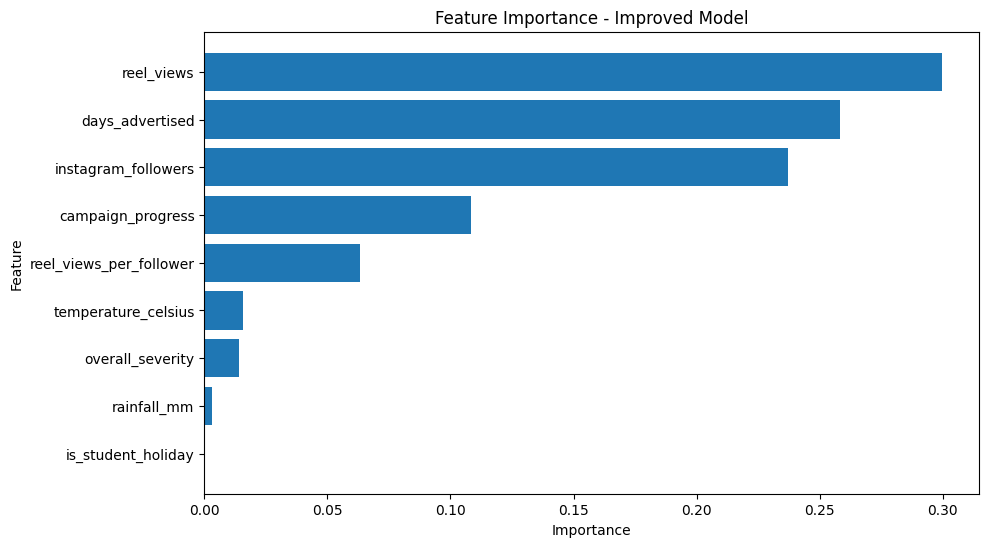

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(feature_importance["feature"], feature_importance["importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Improved Model")

plt.gca().invert_yaxis()

plt.show()

In [44]:
final_results = pd.DataFrame({"Model": ["Original", "Improved"],"R2": [original_r2, improved_r2],"RMSE": [original_rmse, improved_rmse]})

final_results

,Model,R2,RMSE
0,Original,0.855717,7.976757
1,Improved,0.848342,8.178096


In [45]:
r2_change = improved_r2 - original_r2
rmse_change = improved_rmse - original_rmse

print(f"R² change: {r2_change:+.3f}")
print(f"RMSE change: {rmse_change:+.2f}")

R² change: -0.007
RMSE change: +0.20


In [46]:
print("As the data shows the value of both R² and RMSE metrics have approximately remained the same within the improved model, this suggests that engineered features may not have provided significant predictive information. This is acceptable as this project is an experiment.")

As the data shows the value of both R² and RMSE metrics have approximately remained the same within the improved model, this suggests that engineered features may not have provided significant predictive information. This is acceptable as this project is an experiment.


In [48]:
import joblib

joblib.dump(improved_model, "../models/improved_model.pkl")

['../models/improved_model.pkl']

In [49]:
model = joblib.load("../models/improved_model.pkl")

In [51]:
df.to_csv("../data/JE001_engineered.csv", index=False)